<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2004h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running QFT2004h λ-scan...
λ = 0.000 | C_final = 0.9992, width_final = 0.7599, peak_final = 0.9567
λ = 0.250 | C_final = 0.9584, width_final = 1.1483, peak_final = 0.3901
λ = 0.500 | C_final = 0.9339, width_final = 1.2626, peak_final = 0.2879
λ = 0.750 | C_final = 0.9187, width_final = 1.3244, peak_final = 0.2386
λ = 1.000 | C_final = 0.9081, width_final = 1.3651, peak_final = 0.2083
λ = 1.250 | C_final = 0.9002, width_final = 1.3948, peak_final = 0.1871
λ = 1.500 | C_final = 0.8939, width_final = 1.4180, peak_final = 0.1714
λ = 1.750 | C_final = 0.8888, width_final = 1.4369, peak_final = 0.1591
λ = 2.000 | C_final = 0.8845, width_final = 1.4527, peak_final = 0.1491


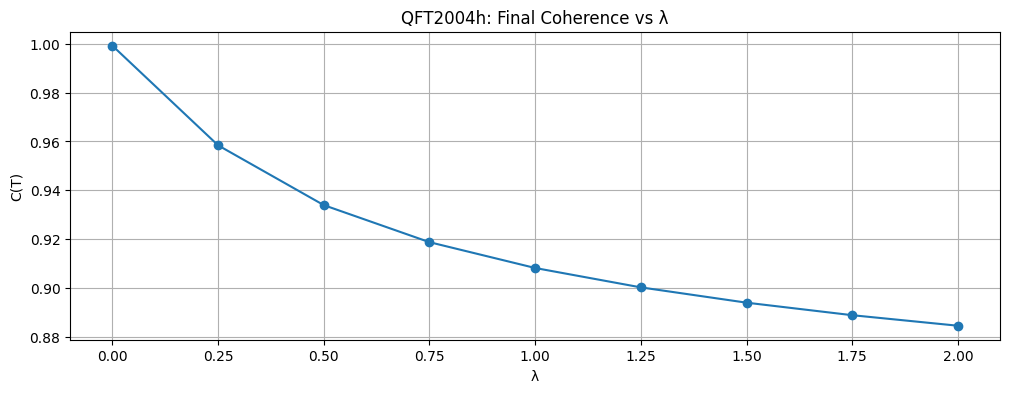

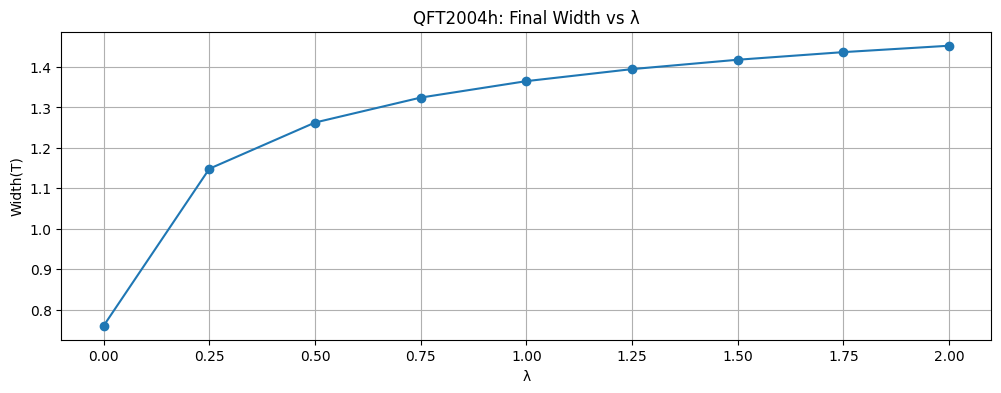

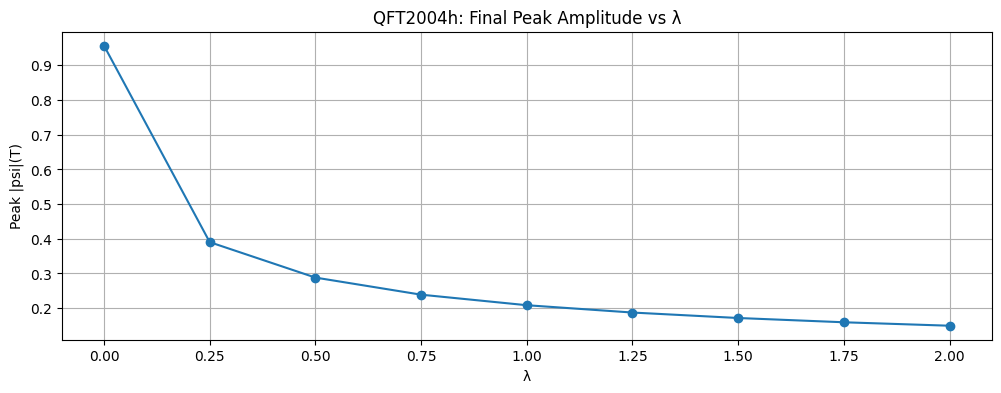


QFT2004h summary table:
  λ = 0.000 | C_final = 0.9992, width_final = 0.7599, peak_final = 0.9567
  λ = 0.250 | C_final = 0.9584, width_final = 1.1483, peak_final = 0.3901
  λ = 0.500 | C_final = 0.9339, width_final = 1.2626, peak_final = 0.2879
  λ = 0.750 | C_final = 0.9187, width_final = 1.3244, peak_final = 0.2386
  λ = 1.000 | C_final = 0.9081, width_final = 1.3651, peak_final = 0.2083
  λ = 1.250 | C_final = 0.9002, width_final = 1.3948, peak_final = 0.1871
  λ = 1.500 | C_final = 0.8939, width_final = 1.4180, peak_final = 0.1714
  λ = 1.750 | C_final = 0.8888, width_final = 1.4369, peak_final = 0.1591
  λ = 2.000 | C_final = 0.8845, width_final = 1.4527, peak_final = 0.1491


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004h — Shape Memory Phase Portrait (λ-scan)
# ============================================================

# --- Lattice parameters ---
N = 512
L = 50.0
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

# --- Time parameters ---
dt = 0.002
steps = 6000  # same horizon as QFT2004g
t_final = steps * dt

# --- Physical parameters (fixed except λ) ---
m = 1.0
A = 1.0
sigma = 1.2
k0 = 1.5

# --- Initial packet (reference shape) ---
psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)

# --- Precompute FFT wave numbers ---
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# --- Helper functions ---
def compute_width(field):
    norm = np.sum(field**2)
    mean = np.sum(x * field**2) / norm
    var = np.sum((x - mean)**2 * field**2) / norm
    return np.sqrt(var)

def compute_coherence(field, ref):
    num = np.abs(np.sum(field * ref))
    den = np.sqrt(np.sum(field**2) * np.sum(ref**2))
    return num / den

def evolve_and_measure(lam, steps=steps, dt=dt):
    """
    Evolve psi under given λ and return:
      - final coherence with psi0
      - final width
      - final peak amplitude
    """
    psi = psi0.copy()
    for step in range(steps):
        # Nonlinear step
        psi_nl = psi - dt * lam * psi**3

        # Linear step via FFT
        psi_k = np.fft.fft(psi_nl)
        psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
        psi = np.real(np.fft.ifft(psi_k))

    C_final = compute_coherence(psi, psi0)
    width_final = compute_width(psi)
    peak_final = np.max(np.abs(psi))
    return C_final, width_final, peak_final

# ============================================================
# λ-scan
# ============================================================

# Choose λ values to scan
lambda_values = np.linspace(0.0, 2.0, 9)  # 0.0, 0.25, ..., 2.0

C_finals = []
width_finals = []
peak_finals = []

print("Running QFT2004h λ-scan...")
for lam in lambda_values:
    C_final, w_final, p_final = evolve_and_measure(lam)
    C_finals.append(C_final)
    width_finals.append(w_final)
    peak_finals.append(p_final)
    print(f"λ = {lam:.3f} | C_final = {C_final:.4f}, width_final = {w_final:.4f}, peak_final = {p_final:.4f}")

C_finals = np.array(C_finals)
width_finals = np.array(width_finals)
peak_finals = np.array(peak_finals)

# ============================================================
# Plotting: Shape Memory vs λ
# ============================================================

plt.figure(figsize=(12,4))
plt.plot(lambda_values, C_finals, 'o-', label="Final coherence C(T)")
plt.xlabel("λ")
plt.ylabel("C(T)")
plt.title("QFT2004h: Final Coherence vs λ")
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(lambda_values, width_finals, 'o-', label="Final width")
plt.xlabel("λ")
plt.ylabel("Width(T)")
plt.title("QFT2004h: Final Width vs λ")
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(lambda_values, peak_finals, 'o-', label="Final peak amplitude")
plt.xlabel("λ")
plt.ylabel("Peak |psi|(T)")
plt.title("QFT2004h: Final Peak Amplitude vs λ")
plt.grid()
plt.show()

# ============================================================
# Printed summary
# ============================================================
print("\nQFT2004h summary table:")
for lam, Cf, wf, pf in zip(lambda_values, C_finals, width_finals, peak_finals):
    print(f"  λ = {lam:.3f} | C_final = {Cf:.4f}, width_final = {wf:.4f}, peak_final = {pf:.4f}")
